# Fase 1 - Analisis Exploratorio de Datos (EDA)

**Proyecto:** Priorizacion de brigadas de salud en comunidades rurales de Colombia.

**Objetivo:** cargar el dataset simulado, describirlo, visualizar sus variables y detectar problemas de calidad (nulos, outliers, desbalance de clases, rangos) para preparar la fase de modelado.

**Fuente:** `output/dataset_completo.csv` (37 columnas). La version lista para modelado `dataset_ml.csv` se menciona al final.

> Ejecuta las celdas en orden (en Colab: *Entorno de ejecucion -> Ejecutar todas*). Si saltas la celda de carga, `df` no existira y veras un `NameError`.

## 0. Configuracion

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

print('Librerias cargadas correctamente')

Librerias cargadas correctamente


## 1. Carga y descripcion del dataset

En Google Colab, ejecuta esta celda: si el archivo no esta en el directorio de trabajo, te pedira subir `dataset_completo.csv`.

In [2]:
RUTA = None

candidatos = [p for p in
              ['dataset_completo.csv', 'output/dataset_completo.csv',
               '../output/dataset_completo.csv'] if os.path.exists(p)]
candidatos += glob.glob('**/dataset_completo.csv', recursive=True)

if candidatos:
    RUTA = candidatos[0]
else:
    try:
        from google.colab import files
        print('Sube el archivo dataset_completo.csv...')
        subidos = files.upload()
        csvs = [n for n in subidos if n.lower().endswith('.csv')]
        if not csvs:
            raise RuntimeError('No se subio ningun archivo CSV.')
        RUTA = csvs[0]
    except ImportError as exc:
        raise FileNotFoundError('No se encontro dataset_completo.csv. Ejecuta primero generar_dataset.py.') from exc

df = pd.read_csv(RUTA, encoding='utf-8-sig')

print('Archivo cargado:', RUTA)
print('Filas:', df.shape[0])
print('Columnas:', df.shape[1])

Archivo cargado: output/dataset_completo.csv
Filas: 10000
Columnas: 37


In [3]:
print('Tipos de datos por columna:')
print(df.dtypes.to_string())

print()
print('Primeras 5 filas:')
df.head()

Tipos de datos por columna:
comunidad_id                 object
departamento                 object
municipio                    object
zona_geografica              object
tipo_comunidad               object
altitud_msnm                  int64
poblacion_total               int64
menores_5                     int64
adultos_mayores               int64
gestantes                     int64
personas_discapacidad         int64
distancia_km                float64
tiempo_acceso_min           float64
acceso_vial                  object
transporte_disponible        object
agua_potable                  int64
alcantarillado                int64
puesto_salud_cercano          int64
cobertura_salud_pct         float64
cobertura_vacunacion_pct    float64
casos_prioritarios_30d        int64
enfermedades_cronicas         int64
alerta_epidemiologica         int64
ultima_brigada_dias           int64
brigadas_ultimos_12m          int64
demanda_insatisfecha_pct    float64
conectividad                 object


,comunidad_id,departamento,municipio,zona_geografica,tipo_comunidad,altitud_msnm,poblacion_total,menores_5,adultos_mayores,gestantes,personas_discapacidad,distancia_km,tiempo_acceso_min,acceso_vial,transporte_disponible,agua_potable,alcantarillado,puesto_salud_cercano,cobertura_salud_pct,cobertura_vacunacion_pct,casos_prioritarios_30d,enfermedades_cronicas,alerta_epidemiologica,ultima_brigada_dias,brigadas_ultimos_12m,demanda_insatisfecha_pct,conectividad,temporada,riesgo_inundacion,riesgo_deslizamiento,indice_necesidad,indice_acceso,indice_vulnerabilidad,indice_brecha,puntaje_prioridad,prioridad,split
0,COM-00001,Putumayo,San Miguel,Amazonía,Campesina,848,363,68,24,10,13,63.66,472.70,Muy difícil,Fluvial + Terrestre,1,1,0,65.25,54.52,5,19,0,169,2,52.24,Baja,Seca,0.46,0.53,48.88,86.83,40.32,62.02,58.60,ALTA,train
1,COM-00002,Cundinamarca,La Palma,Andina,Campesina,2889,137,16,21,5,5,32.73,128.40,Bueno,Terrestre,0,0,0,61.61,67.39,0,13,0,140,3,40.67,Regular,Seca,0.18,0.50,19.27,42.05,73.66,53.77,40.65,BAJA,train
2,COM-00003,Chocó,Unguía,Pacífica,Rural dispersa,86,479,60,65,16,31,57.88,597.94,Muy difícil,Fluvial,1,0,0,61.65,49.33,2,46,0,131,0,18.16,Buena,Transición,0.58,0.35,41.51,83.94,60.70,43.64,58.78,ALTA,train
3,COM-00004,Nariño,Cumbitara,Andina,Indígena,2366,163,24,10,9,6,6.24,10.64,Difícil,Terrestre,0,0,1,71.87,89.35,1,8,0,189,0,20.17,Buena,Seca,0.27,0.65,32.64,20.25,68.26,31.69,30.92,BAJA,train
4,COM-00005,Huila,La Argentina,Andina,Rural,779,417,38,47,12,31,12.22,20.47,Bueno,Terrestre,1,1,0,78.89,70.39,1,37,0,316,1,17.23,Sin conexión,Seca,0.40,0.38,27.35,10.20,39.07,66.39,28.86,BAJA,train


### 1.1 Diccionario de columnas

| Grupo | Columnas |
|---|---|
| Identificacion | `comunidad_id` |
| Geografia | `departamento`, `municipio`, `zona_geografica`, `altitud_msnm` |
| Comunidad | `tipo_comunidad` |
| Demografia | `poblacion_total`, `menores_5`, `adultos_mayores`, `gestantes`, `personas_discapacidad` |
| Acceso / logistica | `distancia_km`, `tiempo_acceso_min`, `acceso_vial`, `transporte_disponible` |
| Servicios | `agua_potable`, `alcantarillado`, `puesto_salud_cercano` |
| Salud | `cobertura_salud_pct`, `cobertura_vacunacion_pct`, `casos_prioritarios_30d`, `enfermedades_cronicas`, `alerta_epidemiologica`, `ultima_brigada_dias`, `brigadas_ultimos_12m`, `demanda_insatisfecha_pct` |
| Ambiente / conectividad | `conectividad`, `temporada`, `riesgo_inundacion`, `riesgo_deslizamiento` |
| Indices (intermedios) | `indice_necesidad`, `indice_acceso`, `indice_vulnerabilidad`, `indice_brecha` |
| Objetivos | `puntaje_prioridad` (regresion), `prioridad` (clasificacion), `split` |

In [4]:
numericas = df.select_dtypes(include=[np.number])
print('Estadisticas descriptivas de variables numericas:')
numericas.describe().T.round(2)

Estadisticas descriptivas de variables numericas:


,count,mean,std,min,25%,50%,75%,max
altitud_msnm,10000.0,1408.93,968.50,0.00,387.00,1436.00,2180.00,3966.00
poblacion_total,10000.0,441.77,383.93,50.00,199.00,333.00,550.00,4612.00
menores_5,10000.0,70.98,67.29,4.00,30.00,51.00,88.00,894.00
adultos_mayores,10000.0,50.24,49.54,2.00,20.00,36.00,63.00,723.00
gestantes,10000.0,13.86,14.88,0.00,5.00,9.00,17.00,213.00
personas_discapacidad,10000.0,19.18,20.37,0.00,7.00,13.00,24.00,293.00
distancia_km,10000.0,35.77,24.11,1.00,17.93,30.53,48.14,180.00
tiempo_acceso_min,10000.0,149.75,159.25,1.65,47.43,96.74,192.98,1920.62
agua_potable,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
alcantarillado,10000.0,0.27,0.44,0.00,0.00,0.00,1.00,1.00


In [5]:
categoricas = df.select_dtypes(include=['object']).columns
for col in categoricas:
    print('===', col, '(', df[col].nunique(), 'categorias )===')
    print(df[col].value_counts().to_string())
    print()

=== comunidad_id ( 10000 categorias )===
comunidad_id
COM-00001    1
COM-00002    1
COM-00003    1
COM-00004    1
COM-00005    1
COM-00006    1
COM-00007    1
COM-00008    1
COM-00009    1
COM-00010    1
COM-00011    1
COM-00012    1
COM-00013    1
COM-00014    1
COM-00015    1
COM-00016    1
COM-00017    1
COM-00018    1
COM-00019    1
COM-00020    1
COM-00021    1
COM-00022    1
COM-00023    1
COM-00024    1
COM-00025    1
COM-00026    1
COM-00027    1
COM-00028    1
COM-00029    1
COM-00030    1
COM-00031    1
COM-00032    1
COM-00033    1
COM-00034    1
COM-00035    1
COM-00036    1
COM-00037    1
COM-00038    1
COM-00039    1
COM-00040    1
COM-00041    1
COM-00042    1
COM-00043    1
COM-00044    1
COM-00045    1
COM-00046    1
COM-00047    1
COM-00048    1
COM-00049    1
COM-00050    1
COM-00051    1
COM-00052    1
COM-00053    1
COM-00054    1
COM-00055    1
COM-00056    1
COM-00057    1
COM-00058    1
COM-00059    1
COM-00060    1
COM-00061    1
COM-00062    1
COM-00063    1
C

## 2. Estadisticas descriptivas y visualizaciones

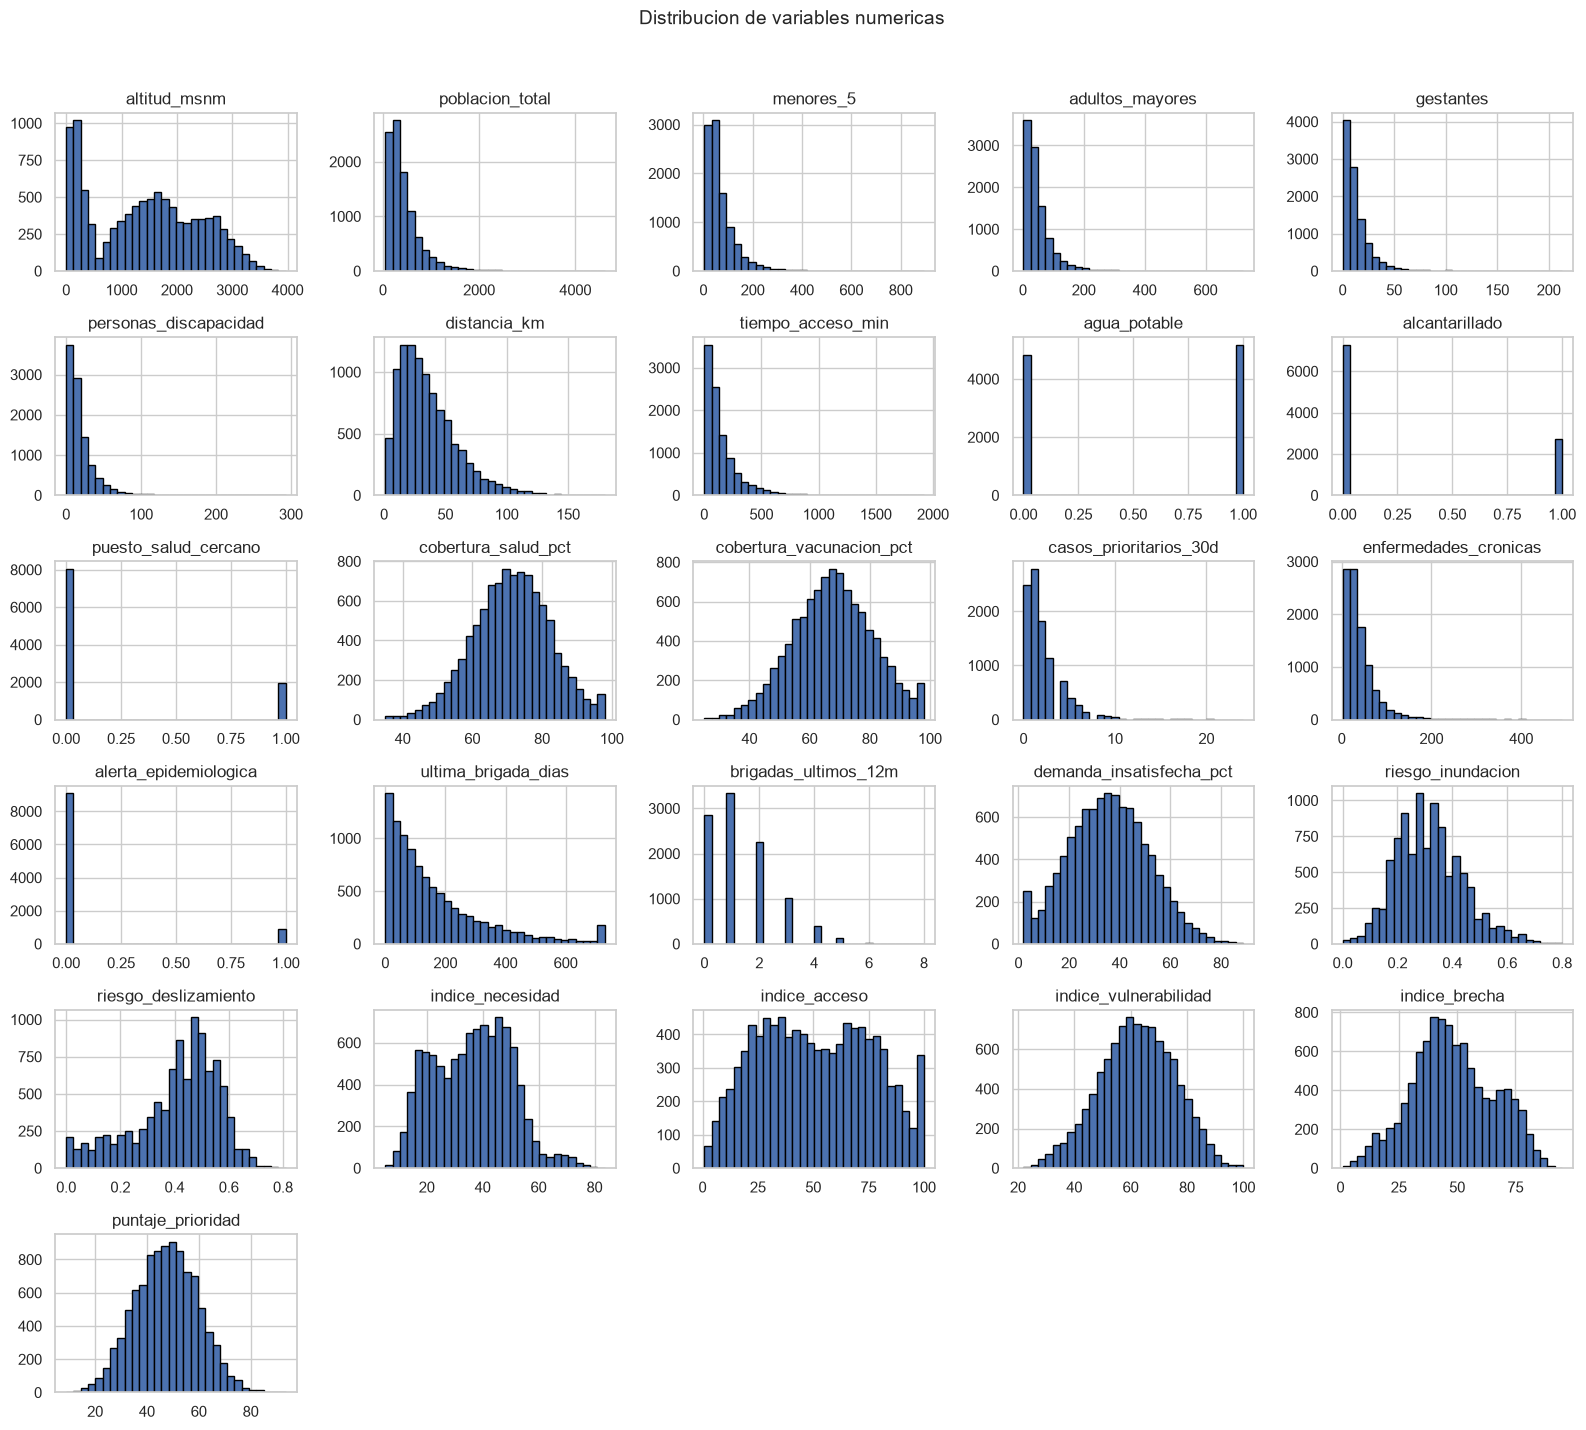

In [6]:
cols_num = df.select_dtypes(include=[np.number]).columns.tolist()

df[cols_num].hist(bins=30, figsize=(16, 14), edgecolor='black')
plt.suptitle('Distribucion de variables numericas', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

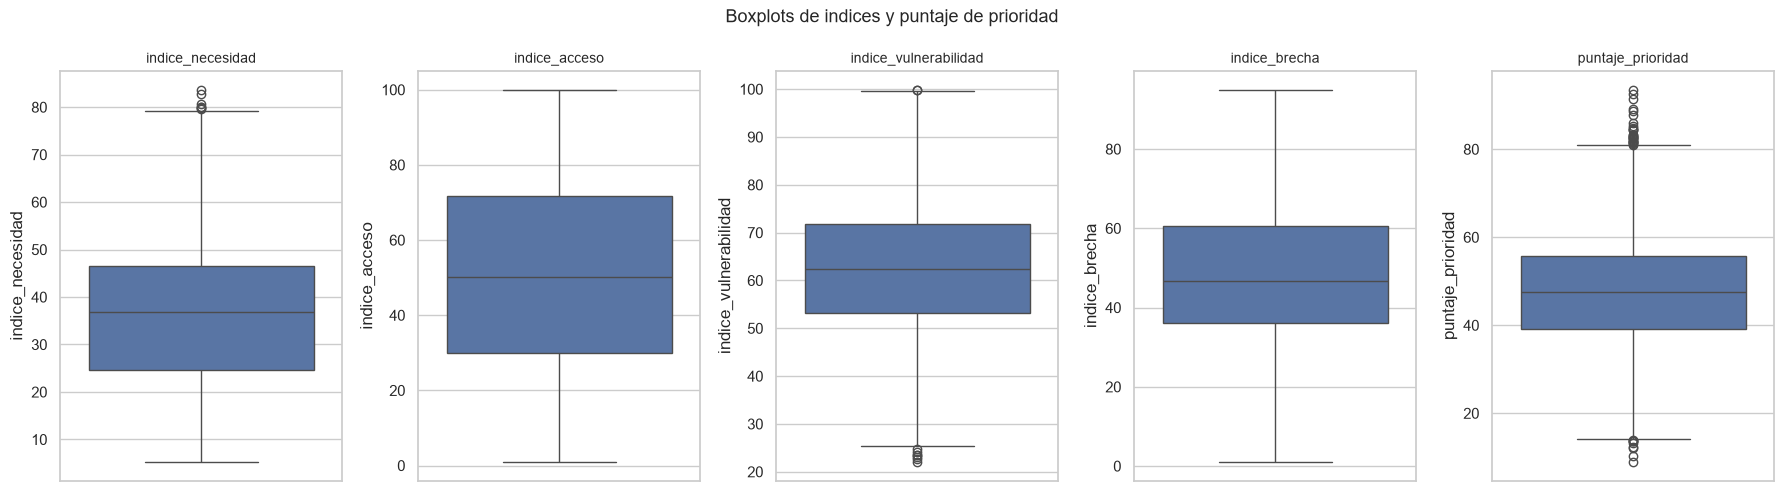

In [7]:
indices = ['indice_necesidad', 'indice_acceso', 'indice_vulnerabilidad',
           'indice_brecha', 'puntaje_prioridad']

fig, axes = plt.subplots(1, len(indices), figsize=(18, 5))
for ax, col in zip(axes, indices):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=10)
plt.suptitle('Boxplots de indices y puntaje de prioridad', fontsize=13)
plt.tight_layout()
plt.show()

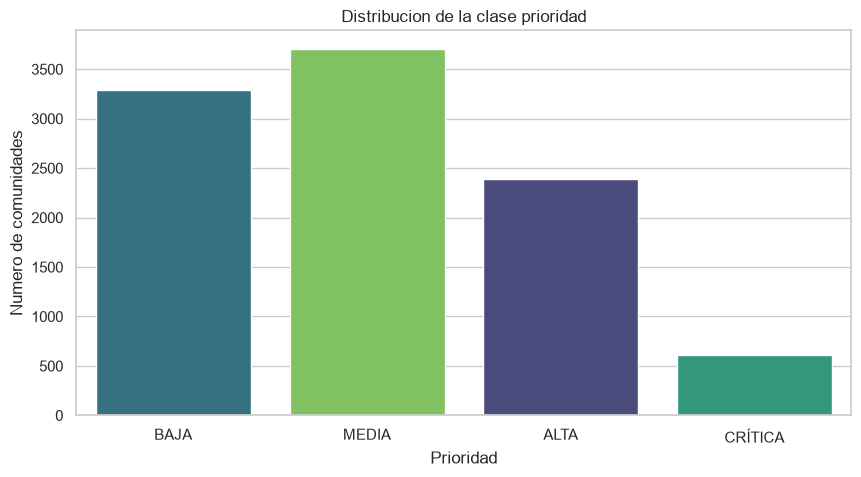

In [8]:
orden = ['BAJA', 'MEDIA', 'ALTA', 'CRÍTICA']

sns.countplot(data=df, x='prioridad', order=orden, hue='prioridad', legend=False, palette='viridis')
plt.title('Distribucion de la clase prioridad')
plt.xlabel('Prioridad')
plt.ylabel('Numero de comunidades')
plt.show()

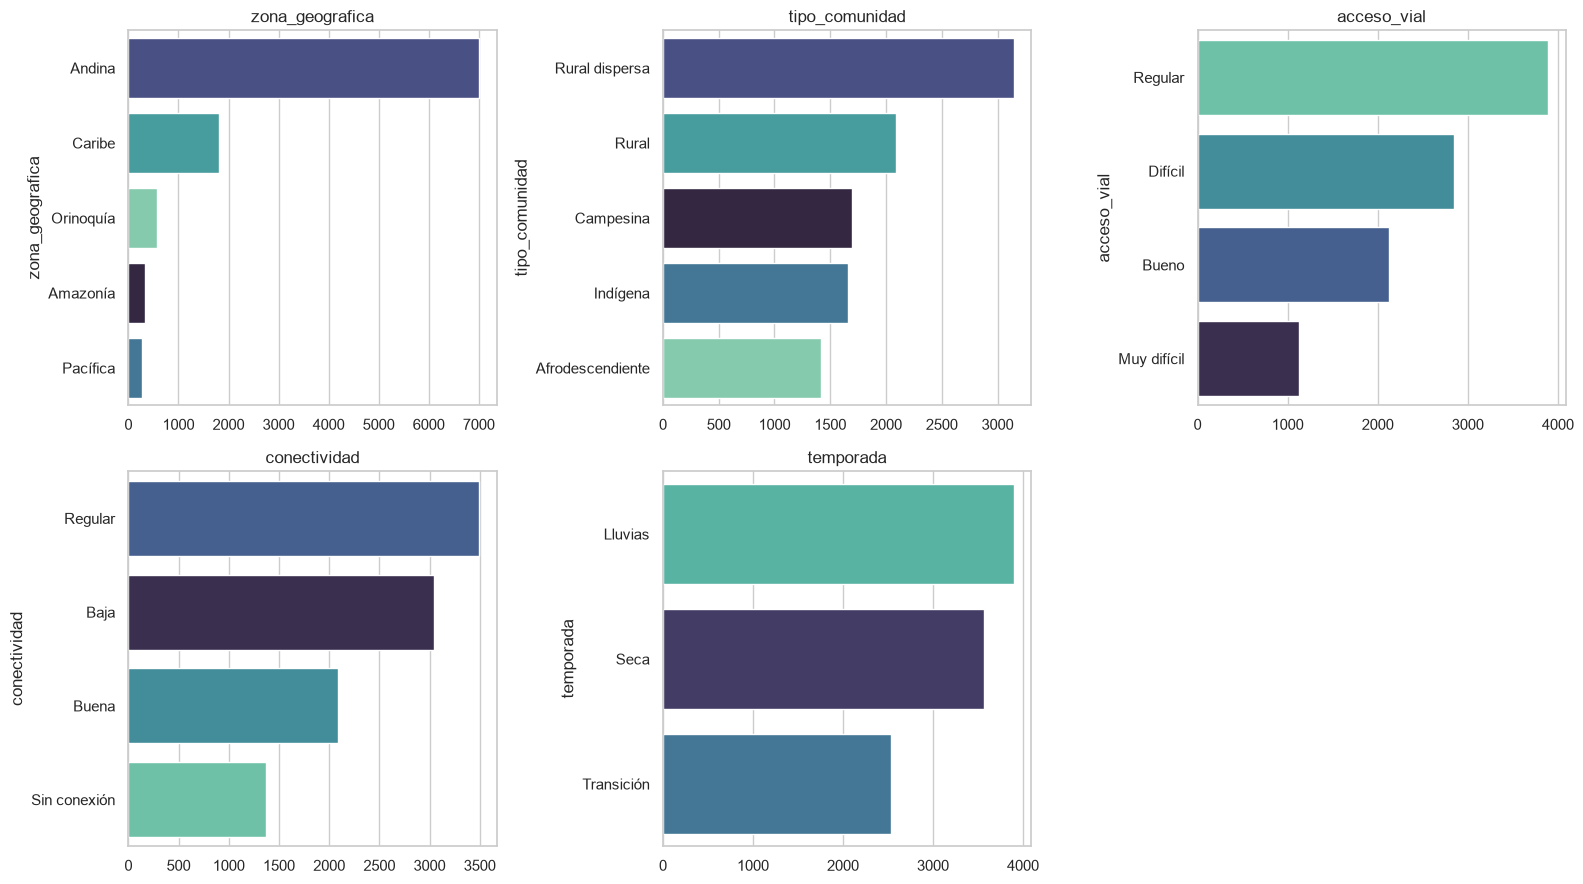

In [9]:
cats = ['zona_geografica', 'tipo_comunidad', 'acceso_vial', 'conectividad', 'temporada']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), cats):
    sns.countplot(data=df, y=col, ax=ax, hue=col, legend=False,
                  order=df[col].value_counts().index, palette='mako')
    ax.set_title(col)
    ax.set_xlabel('')
for ax in axes.ravel()[len(cats):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

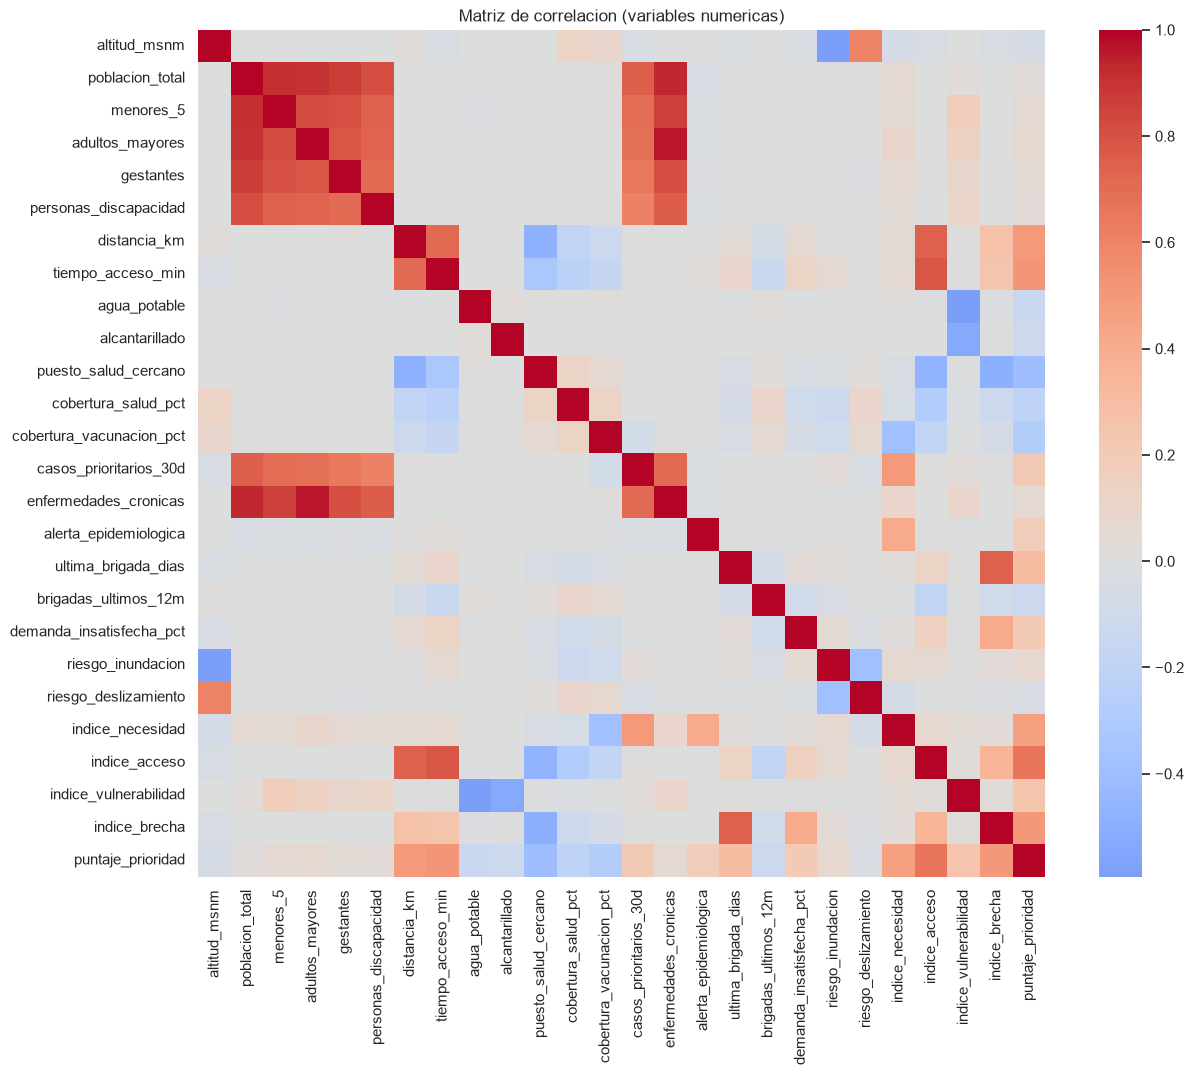

In [10]:
corr = df[cols_num].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
plt.title('Matriz de correlacion (variables numericas)')
plt.show()

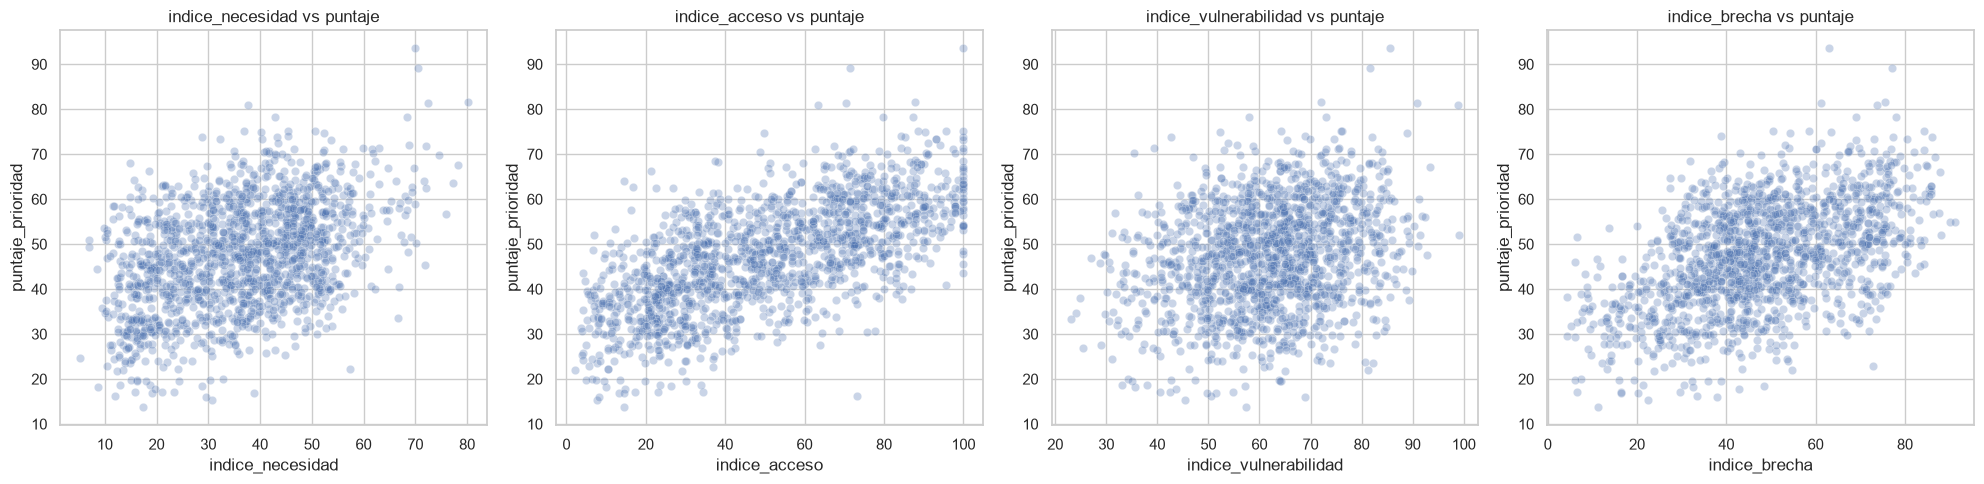

In [11]:
muestra = df.sample(1500, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, indices[:4]):
    sns.scatterplot(data=muestra, x=col, y='puntaje_prioridad', ax=ax, alpha=0.3)
    ax.set_title(col + ' vs puntaje')
plt.tight_layout()
plt.show()

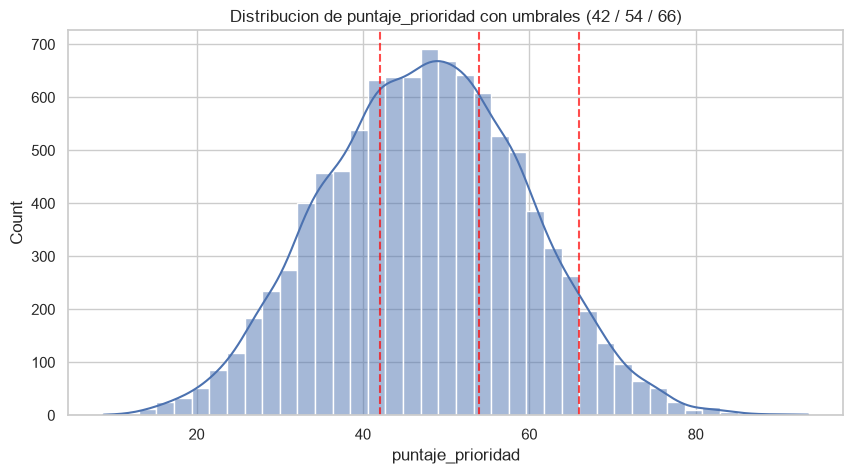

In [12]:
umbrales = {'BAJA': 42, 'MEDIA': 54, 'ALTA': 66}

sns.histplot(df['puntaje_prioridad'], bins=40, kde=True, color='#4C72B0')
for valor in umbrales.values():
    plt.axvline(valor, color='red', linestyle='--', alpha=0.7)
plt.title('Distribucion de puntaje_prioridad con umbrales (42 / 54 / 66)')
plt.xlabel('puntaje_prioridad')
plt.show()

## 3. Calidad de datos

In [13]:
nulos = df.isna().sum()
print('Valores nulos por columna:')
if nulos.any():
    print(nulos[nulos > 0].to_string())
else:
    print('  (ninguno)')

print()
print('Filas duplicadas:', df.duplicated().sum())
print('IDs duplicados:', df['comunidad_id'].duplicated().sum())

Valores nulos por columna:
  (ninguno)

Filas duplicadas: 0
IDs duplicados: 0


In [14]:
resumen = []
for col in cols_num:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df[col] < li) | (df[col] > ls)).sum())
    resumen.append((col, n_out, round(n_out / len(df) * 100, 2), round(li, 2), round(ls, 2)))

outliers = pd.DataFrame(resumen, columns=['columna', 'n_outliers', 'pct', 'lim_inf', 'lim_sup'])
print('Outliers por el metodo IQR (1.5):')
outliers.sort_values('n_outliers', ascending=False).reset_index(drop=True)

Outliers por el metodo IQR (1.5):


,columna,n_outliers,pct,lim_inf,lim_sup
0,puesto_salud_cercano,1954,19.54,0.00,0.00
1,alerta_epidemiologica,901,9.01,0.00,0.00
2,tiempo_acceso_min,689,6.89,-170.90,411.31
3,personas_discapacidad,679,6.79,-18.50,49.50
4,gestantes,664,6.64,-13.00,35.00
5,menores_5,642,6.42,-57.00,175.00
6,adultos_mayores,599,5.99,-44.50,127.50
7,poblacion_total,584,5.84,-327.50,1076.50
8,enfermedades_cronicas,565,5.65,-34.00,102.00
9,ultima_brigada_dias,522,5.22,-230.50,509.50


In [15]:
conteo = df['prioridad'].value_counts()
porcentaje = (conteo / len(df) * 100).round(2)
tabla = pd.DataFrame({'conteo': conteo, 'porcentaje': porcentaje})
print('Balance de clases de prioridad:')
print(tabla.to_string())
print()
print('Ratio clase mayor/menor:', round(conteo.max() / conteo.min(), 2))

Balance de clases de prioridad:
           conteo  porcentaje
prioridad                    
MEDIA        3707       37.07
BAJA         3294       32.94
ALTA         2387       23.87
CRÍTICA       612        6.12

Ratio clase mayor/menor: 6.06


In [16]:
binarias = ['agua_potable', 'alcantarillado', 'puesto_salud_cercano', 'alerta_epidemiologica']
for col in binarias:
    print(col, '->', sorted(df[col].unique()))

print()
print('Rangos observados:')
print('cobertura_salud_pct     :', df['cobertura_salud_pct'].min(), '-', df['cobertura_salud_pct'].max())
print('cobertura_vacunacion_pct:', df['cobertura_vacunacion_pct'].min(), '-', df['cobertura_vacunacion_pct'].max())
print('riesgo_inundacion       :', df['riesgo_inundacion'].min(), '-', df['riesgo_inundacion'].max())
print('puntaje_prioridad       :', df['puntaje_prioridad'].min(), '-', df['puntaje_prioridad'].max())

agua_potable -> [np.int64(0), np.int64(1)]
alcantarillado -> [np.int64(0), np.int64(1)]
puesto_salud_cercano -> [np.int64(0), np.int64(1)]
alerta_epidemiologica -> [np.int64(0), np.int64(1)]

Rangos observados:
cobertura_salud_pct     : 35.0 - 98.0
cobertura_vacunacion_pct: 25.0 - 98.0
riesgo_inundacion       : 0.0 - 0.8
puntaje_prioridad       : 8.83 - 93.52


In [17]:
print('Registros por split:')
print(df['split'].value_counts().to_string())

Registros por split:
split
train    6999
test     1556
val      1445


## 4. Conclusiones

- El dataset no presenta valores nulos ni filas duplicadas.
- Las variables numericas tienen rangos coherentes con su definicion.
- La clase `prioridad` es ordinal y moderadamente desbalanceada; conviene reportar metricas macro y tenerlo en cuenta al modelar.
- La version para modelado es `dataset_ml.csv`: 29 features + `puntaje_prioridad` (regresion) + `prioridad` + `split`. Los indices `indice_*` y `comunidad_id` se excluyen para evitar fuga de informacion.
- Siguiente fase: entrenar la red feedforward (29 entradas -> `puntaje_prioridad`) y derivar la clase con los umbrales 42 / 54 / 66.